# Synthetic ARMA Conditional Diffusion Experiment

This notebook reproduces the synthetic ARMA-style experiment in the refactored project. It trains the conditional recurrent diffusion model on simulated multivariate ARMA monthly returns, evaluates generated paths with the same mean/std/ACF1 diagnostics, runs the generated-scenario Markowitz backtest against 1/N, plots wealth and diagnostics, and saves RL-ready scenario tensors including RNN features.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model


In [3]:
from pathlib import Path
import sys

# Works whether the notebook is run from repo root or notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from portfolio_diffusion import (
    DDPMConfig,
    ConditionalRecurrentDDPM,
    TrainCfg,
    seed_everything,
    fit,
    build_dataloader,
    simulate_arma_returns,
    run_generative_markowitz_backtest,
    make_backtest_dataframe,
    performance_stats,
    compute_rebalance_turnover,
    build_weight_dataframe,
    build_average_weights_dataframe,
    save_scenario_dataset_for_rl,
    generated_path_diagnostics,
    correlation_mae,
)
from portfolio_diffusion.plotting import plot_wealth, plot_average_weights, plot_turnover

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "arma_synthetic"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

seed_everything(42)
print("Project root:", PROJECT_ROOT)
print("Output dir:", OUTPUT_DIR)
print("CUDA available:", torch.cuda.is_available())

Project root: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model
Output dir: /content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/outputs/arma_synthetic
CUDA available: True


## 1. Simulate multivariate ARMA returns

The synthetic data are decimal monthly returns. The ARMA process has correlated innovations and small asset-specific drifts so that the portfolio experiment has a non-trivial mean signal.


In [4]:
# -------------------------
# Simulation settings
# -------------------------
T_TOTAL = 3200
NUM_ASSETS = 5
BURN_IN = 500
SEED = 123

asset_names = [f"Asset_{i+1}" for i in range(NUM_ASSETS)]

returns = simulate_arma_returns(
    T=T_TOTAL,
    num_assets=NUM_ASSETS,
    ar=(0.35,),
    ma=(0.25,),
    sigma=0.030,
    corr=0.30,
    burn_in=BURN_IN,
    seed=SEED,
)

# Add small monthly drifts. This makes the portfolio test meaningful.
monthly_drift = np.linspace(0.0010, 0.0040, NUM_ASSETS).astype(np.float32)
returns = returns + monthly_drift

# Monthly date index for synthetic data.
dates = pd.date_range("1950-01-31", periods=T_TOTAL, freq="ME")
returns_df = pd.DataFrame(returns, index=dates, columns=asset_names)

print("Synthetic ARMA shape:", returns_df.shape)
print("Date range:", returns_df.index.min(), "to", returns_df.index.max())
returns_df.head()

Synthetic ARMA shape: (3200, 5)
Date range: 1950-01-31 00:00:00 to 2216-08-31 00:00:00


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5
1950-01-31,0.020700,0.013116,0.053523,0.053691,0.061777
1950-02-28,0.046813,-0.006782,0.048112,0.004469,0.055187
1950-03-31,0.049060,0.009511,0.032034,0.003622,0.009202
1950-04-30,0.012870,-0.035722,0.028872,0.027672,-0.054579
1950-05-31,-0.040124,-0.030933,-0.021068,0.039792,-0.032890


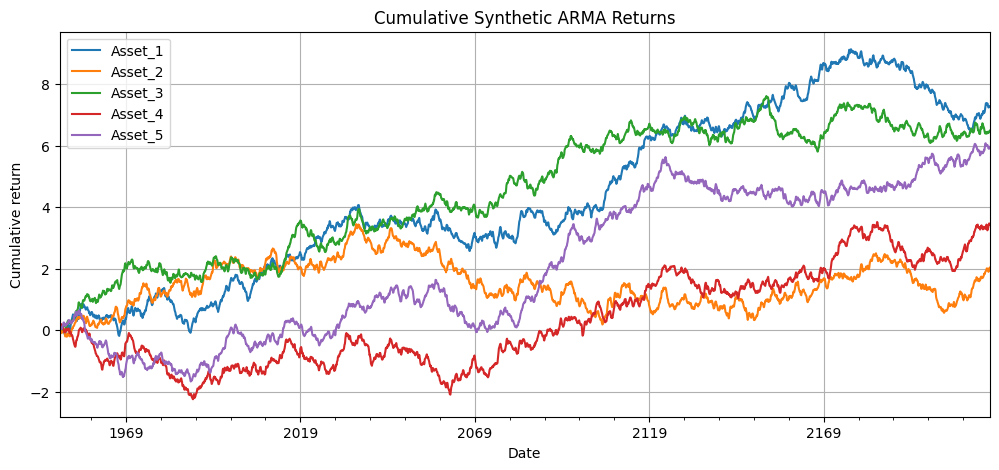

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
returns_df.cumsum().plot(ax=ax)
ax.set_title("Cumulative Synthetic ARMA Returns")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.grid(True)
plt.show()

## 2. Train/validation/test split and standardization

The split is chronological. The model is trained on standardized returns using only train-set mean and standard deviation.


In [6]:
TRAIN_END = 2200
VALID_END = 2600

train_df = returns_df.iloc[:TRAIN_END].copy()
valid_target_df = returns_df.iloc[TRAIN_END:VALID_END].copy()
test_target_df_full = returns_df.iloc[VALID_END:].copy()

print("Train:", train_df.shape, train_df.index.min(), "to", train_df.index.max())
print("Valid:", valid_target_df.shape, valid_target_df.index.min(), "to", valid_target_df.index.max())
print("Test full:", test_target_df_full.shape, test_target_df_full.index.min(), "to", test_target_df_full.index.max())

Train: (2200, 5) 1950-01-31 00:00:00 to 2133-04-30 00:00:00
Valid: (400, 5) 2133-05-31 00:00:00 to 2166-08-31 00:00:00
Test full: (600, 5) 2166-09-30 00:00:00 to 2216-08-31 00:00:00


## 3. Configure the diffusion model

The synthetic experiment uses a smaller model than the FF49 experiment because there are only five assets.


In [7]:
cfg = DDPMConfig(
    input_dim=NUM_ASSETS,
    context_length=20,
    prediction_length=1,
    rnn_type="LSTM",
    rnn_hidden_dim=64,
    rnn_layers=1,
    rnn_dropout=0.0,
    unet_base_channels=32,
    unet_depth=2,
    time_embed_dim=128,
    diffusion_steps=200,
    beta_start=1e-4,
    beta_end=2e-2,
    batch_size=64,
    lr=2e-4,
    epochs=40,
    grad_clip=1.0,
    weight_decay=1e-4,
    device="cuda" if torch.cuda.is_available() else "cpu",
)

device = torch.device(cfg.device)
print("Device:", device)
print(cfg)

Device: cuda
DDPMConfig(input_dim=5, context_length=20, prediction_length=1, rnn_type='LSTM', rnn_hidden_dim=64, rnn_layers=1, rnn_dropout=0.0, unet_base_channels=32, unet_depth=2, time_embed_dim=128, diffusion_steps=200, beta_start=0.0001, beta_end=0.02, lr=0.0002, batch_size=64, epochs=40, grad_clip=1.0, weight_decay=0.0001, device='cuda', scale_condition=1.0)


In [8]:
# Standardize using train statistics only.
train_raw = train_df.values.astype(np.float32)
valid_with_context_df = pd.concat([train_df.iloc[-cfg.context_length:], valid_target_df], axis=0)
valid_raw = valid_with_context_df.values.astype(np.float32)

mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True) + 1e-8

train_returns = (train_raw - mean) / std
valid_returns = (valid_raw - mean) / std

print("Train standardized mean avg:", train_returns.mean(axis=0).mean())
print("Train standardized std avg:", train_returns.std(axis=0).mean())

Train standardized mean avg: -8.2362783e-10
Train standardized std avg: 0.9999997


## 4. Dataloaders

The dataset returns repo-style sequence-to-sequence targets:

```text
context: [batch, context_length, num_assets]
target:  [batch, context_length, prediction_length, num_assets]
```

This gives a diffusion loss for every RNN hidden state inside the context window.


In [9]:
train_dataset, train_loader = build_dataloader(
    series=train_returns,
    cfg=cfg,
    shuffle=True,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=True,
)

valid_dataset, valid_loader = build_dataloader(
    series=valid_returns,
    cfg=cfg,
    shuffle=False,
    stride=1,
    normalize=False,
    num_workers=0,
    drop_last=False,
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(valid_dataset))

batch = next(iter(train_loader))
print("context shape:", batch["context"].shape)
print("target shape:", batch["target"].shape)

Train samples: 2180
Validation samples: 400
context shape: torch.Size([64, 20, 5])
target shape: torch.Size([64, 20, 1, 5])


## 5. Train the conditional diffusion model

In [10]:
model = ConditionalRecurrentDDPM(cfg).to(device)

train_cfg = TrainCfg(
    optim_name="AdamW",
    lr=cfg.lr,
    weight_decay=cfg.weight_decay,
    scheduler="cosine",
    num_epochs=cfg.epochs,
    use_ema=True,
    ema_decay=0.999,
    max_grad_norm=cfg.grad_clip,
    amp=torch.cuda.is_available(),
    patience=15,
    seed=42,
    save_path=str(OUTPUT_DIR / "best_arma_synthetic_ddpm.pt"),
    force_lazy_modules=True,
)

best_model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=valid_loader,
    device=device,
    cfg=train_cfg,
)

pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)
pd.DataFrame(history).tail()

/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:279: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
Epoch 1/40:   0%|          | 0/34 [00:00<?, ?it/s]/content/drive/MyDrive/Research/Solving Dynamic Portfolio by diffusion model/dynamic_portfolio_diffusion_model/portfolio_diffusion/training.py:317: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):


[001/040] train=0.653791 val=0.984720 lr=2.00e-04 t=0.0m


[002/040] train=0.572356 val=0.943955 lr=1.99e-04 t=0.1m


[003/040] train=0.566909 val=0.898695 lr=1.97e-04 t=0.1m


[004/040] train=0.558542 val=0.847512 lr=1.95e-04 t=0.1m


...

[033/040] train=0.498378 val=0.568981 lr=2.40e-05 t=0.7m


[034/040] train=0.499647 val=0.566391 lr=2.04e-05 t=0.7m


[035/040] train=0.501663 val=0.560484 lr=1.72e-05 t=0.7m


[036/040] train=0.500049 val=0.564702 lr=1.46e-05 t=0.8m


KeyboardInterrupt: 

In [ ]:
history_df = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Train")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
ax.set_title("ARMA Diffusion Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)
plt.show()

## 6. Generate autoregressive paths and compute distribution diagnostics

These metrics match the ones we used before:

```text
Mean MAE
Std MAE
ACF1 MAE
```

The ACF1 diagnostic uses autoregressive generated paths because one-step scenario draws alone do not define a time-series autocorrelation.


In [ ]:
# To keep the notebook runtime manageable, the diagnostics/backtest can use a subset
# of the full test period. Set MAX_TEST_MONTHS = None to use the full test set.
MAX_TEST_MONTHS = 360
NUM_DIAGNOSTIC_PATHS = 200

if MAX_TEST_MONTHS is None:
    test_target_df = test_target_df_full.copy()
else:
    test_target_df = test_target_df_full.iloc[:MAX_TEST_MONTHS].copy()

# History immediately before the test window.
test_start_loc = returns_df.index.get_loc(test_target_df.index[0])
history_raw = returns_df.iloc[test_start_loc - cfg.context_length:test_start_loc].values.astype(np.float32)
history_std = (history_raw - mean.reshape(-1)) / std.reshape(-1)

with torch.no_grad():
    path_samples_std, path_rnn_features = best_model.sample_autoregressive(
        history=torch.as_tensor(history_std, dtype=torch.float32, device=device),
        horizon=len(test_target_df),
        num_samples=NUM_DIAGNOSTIC_PATHS,
        eta=1.0,
        clip_x0=None,
    )

# Shapes: [T_test, num_paths, num_assets] and [T_test, num_paths, rnn_hidden_dim]
path_samples_std = path_samples_std.numpy()
path_rnn_features = path_rnn_features.numpy()
path_samples_raw = path_samples_std * std.reshape(1, 1, -1) + mean.reshape(1, 1, -1)

real_test_raw = test_target_df.values.astype(np.float32)
real_test_std = (real_test_raw - mean.reshape(-1)) / std.reshape(-1)

print("Generated standardized paths:", path_samples_std.shape)
print("Generated raw paths:", path_samples_raw.shape)
print("Generated RNN features:", path_rnn_features.shape)
print("Real test shape:", real_test_raw.shape)

In [ ]:
diagnostics_std_df, summary_std = generated_path_diagnostics(
    real_series=real_test_std,
    generated_paths=path_samples_std,
    asset_names=asset_names,
)

corr_mae_std = correlation_mae(real_test_std, path_samples_std)
summary_std["Correlation MAE"] = corr_mae_std

print("Standardized diagnostics summary:")
for k, v in summary_std.items():
    print(f"{k}: {v:.6f}")

diagnostics_std_df

In [ ]:
diagnostics_raw_df, summary_raw = generated_path_diagnostics(
    real_series=real_test_raw,
    generated_paths=path_samples_raw,
    asset_names=asset_names,
)

summary_raw["Correlation MAE"] = correlation_mae(real_test_raw, path_samples_raw)

print("Raw-return diagnostics summary:")
for k, v in summary_raw.items():
    print(f"{k}: {v:.6f}")

diagnostics_raw_df

In [ ]:
diagnostics_std_df.to_csv(OUTPUT_DIR / "arma_generated_path_diagnostics_standardized.csv", index=False)
diagnostics_raw_df.to_csv(OUTPUT_DIR / "arma_generated_path_diagnostics_raw.csv", index=False)
pd.DataFrame({"standardized": summary_std, "raw": summary_raw}).to_csv(OUTPUT_DIR / "arma_generated_path_diagnostics_summary.csv")

np.savez_compressed(
    OUTPUT_DIR / "arma_generated_paths_for_diagnostics.npz",
    generated_paths_raw=path_samples_raw,
    generated_paths_standardized=path_samples_std,
    rnn_features=path_rnn_features,
    real_test_raw=real_test_raw,
    real_test_standardized=real_test_std,
    dates=test_target_df.index.astype(str).to_numpy(),
    asset_names=np.asarray(asset_names),
)

print("Saved diagnostics to", OUTPUT_DIR)

## 7. Plot generated-path diagnostics

In [ ]:
asset_idx = 0
asset_name = asset_names[asset_idx]
q05, q50, q95 = np.quantile(path_samples_raw[:, :, asset_idx], [0.05, 0.50, 0.95], axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_target_df.index, real_test_raw[:, asset_idx], label="Real")
ax.plot(test_target_df.index, q50, label="Generated median")
ax.fill_between(test_target_df.index, q05, q95, alpha=0.20, label="Generated 5%-95%")
ax.set_title(f"Generated ARMA Paths vs Real Test Returns: {asset_name}")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly return")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(diagnostics_std_df["real_std"], diagnostics_std_df["gen_std"])
low = min(diagnostics_std_df["real_std"].min(), diagnostics_std_df["gen_std"].min())
high = max(diagnostics_std_df["real_std"].max(), diagnostics_std_df["gen_std"].max())
ax.plot([low, high], [low, high], linestyle="--")
ax.set_title("Standardized Std: Real vs Generated")
ax.set_xlabel("Real std")
ax.set_ylabel("Generated std")
ax.grid(True)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(diagnostics_std_df["real_acf1"], diagnostics_std_df["gen_acf1"])
low = min(diagnostics_std_df["real_acf1"].min(), diagnostics_std_df["gen_acf1"].min())
high = max(diagnostics_std_df["real_acf1"].max(), diagnostics_std_df["gen_acf1"].max())
ax.plot([low, high], [low, high], linestyle="--")
ax.set_title("Standardized ACF1: Real vs Generated")
ax.set_xlabel("Real ACF1")
ax.set_ylabel("Generated ACF1")
ax.grid(True)
plt.show()

## 8. Rolling generated-scenario Markowitz backtest

At each synthetic test month, the model generates next-month scenarios from the previous context window. We compare generated-scenario Markowitz against monthly rebalanced 1/N.


In [ ]:
NUM_SCENARIOS = 500

backtest_results = run_generative_markowitz_backtest(
    model=best_model,
    monthly_returns_df=returns_df,
    test_target_df=test_target_df,
    mean=mean,
    std=std,
    cfg=cfg,
    num_scenarios=NUM_SCENARIOS,
    risk_aversion=5.0,
    eta=1.0,
    cov_shrinkage=0.05,
    weight_cap=None,
)

bt_df = make_backtest_dataframe(backtest_results)
bt_df.to_csv(OUTPUT_DIR / "arma_backtest_generative_markowitz_vs_equal_weight.csv")
bt_df.head()

In [ ]:
gm_stats = performance_stats(
    bt_df["Generative_Markowitz_Return"].values,
    wealth=bt_df["Generative_Markowitz_Wealth"].values,
)
ew_stats = performance_stats(
    bt_df["Equal_Weight_Return"].values,
    wealth=bt_df["Equal_Weight_Wealth"].values,
)

stats_df = pd.DataFrame({"Generative Markowitz": gm_stats, "1/N Equal Weight": ew_stats})
stats_df.to_csv(OUTPUT_DIR / "arma_performance_stats.csv")
stats_df

In [ ]:
fig, ax = plot_wealth(bt_df)
plt.show()

## 9. Weights, turnover, and transaction costs

In [ ]:
weights_df = build_weight_dataframe(backtest_results, asset_names)
avg_weights_df = build_average_weights_dataframe(weights_df)

weights_df.to_csv(OUTPUT_DIR / "arma_generative_markowitz_monthly_weights.csv")
avg_weights_df.to_csv(OUTPUT_DIR / "arma_average_weights.csv", index=False)

avg_weights_df

In [ ]:
fig, ax = plot_average_weights(avg_weights_df, top_n=NUM_ASSETS)
plt.show()

In [ ]:
R_test = backtest_results["actual_next_returns"]
W_gm = backtest_results["gm_weights"]
T, N = R_test.shape
W_ew = np.ones((T, N)) / N

turnover_gm = compute_rebalance_turnover(W_gm, R_test)
turnover_ew = compute_rebalance_turnover(W_ew, R_test)

turnover_df = pd.DataFrame(
    {"GM_Turnover": turnover_gm, "Equal_Weight_Turnover": turnover_ew},
    index=backtest_results["dates"],
)
turnover_df.to_csv(OUTPUT_DIR / "arma_turnover.csv")

print("Average GM turnover:", turnover_gm.mean())
print("Average 1/N turnover:", turnover_ew.mean())
turnover_df.head()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(turnover_df.index, turnover_df["GM_Turnover"], label="Generative Markowitz")
ax.plot(turnover_df.index, turnover_df["Equal_Weight_Turnover"], label="1/N Equal Weight")
ax.set_title("Drift-Adjusted Monthly Turnover")
ax.set_xlabel("Date")
ax.set_ylabel("Turnover")
ax.legend()
ax.grid(True)
plt.show()

In [ ]:
cost_rows = []
for cost_bps in [0, 5, 10, 25, 50]:
    c = cost_bps / 10000.0

    gm_net = bt_df["Generative_Markowitz_Return"].values - c * turnover_gm
    ew_net = bt_df["Equal_Weight_Return"].values - c * turnover_ew

    gm_net_wealth = np.cumprod(1.0 + gm_net)
    ew_net_wealth = np.cumprod(1.0 + ew_net)

    gm_net_stats = performance_stats(gm_net, wealth=gm_net_wealth)
    ew_net_stats = performance_stats(ew_net, wealth=ew_net_wealth)

    cost_rows.append({
        "Cost_bps": cost_bps,
        "GM_Final_Wealth": gm_net_stats["Final Wealth"],
        "EW_Final_Wealth": ew_net_stats["Final Wealth"],
        "GM_Sharpe": gm_net_stats["Sharpe"],
        "EW_Sharpe": ew_net_stats["Sharpe"],
        "GM_Max_Drawdown": gm_net_stats["Max Drawdown"],
        "EW_Max_Drawdown": ew_net_stats["Max Drawdown"],
    })

cost_df = pd.DataFrame(cost_rows)
cost_df.to_csv(OUTPUT_DIR / "arma_transaction_cost_sensitivity.csv", index=False)
cost_df

## 10. Save RL-ready generated scenario dataset

This saves the same kind of tensor files as the FF49 notebook, including:

```text
scenarios_raw: [T_test, num_scenarios, num_assets]
rnn_features:  [T_test, num_scenarios, rnn_hidden_dim]
actual_next_returns: [T_test, num_assets]
history_windows_raw: [T_test, context_length, num_assets]
```


In [ ]:
saved_paths = save_scenario_dataset_for_rl(
    backtest_results=backtest_results,
    asset_names=asset_names,
    output_dir=OUTPUT_DIR,
    prefix="arma_diffusion",
)

for name, path in saved_paths.items():
    print(name, "->", path)

In [ ]:
rl_data = np.load(OUTPUT_DIR / "arma_diffusion_scenarios_for_rl.npz")
print("scenarios_raw:", rl_data["scenarios_raw"].shape)
print("rnn_features:", rl_data["rnn_features"].shape)
print("actual_next_returns:", rl_data["actual_next_returns"].shape)
print("history_windows_raw:", rl_data["history_windows_raw"].shape)
print("dates:", rl_data["dates"][:3])